In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# !kaggle datasets download -d undefinenull/million-song-dataset-spotify-lastfm


In [3]:
# import zipfile

# with zipfile.ZipFile("million-song-dataset-spotify-lastfm.zip", 'r') as zip_ref:
#     zip_ref.extractall("data")  # extracts into a folder named 'data'


In [4]:
song_data_path = os.path.join("data", "Music Info.csv")
users_data_path = os.path.join("data","User Listening History.csv")

In [5]:
song_data_path

'data\\Music Info.csv'

In [6]:
df_song = pd.read_csv(song_data_path)

In [7]:
df_song.info()

<class 'pandas.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  str    
 1   name                 50683 non-null  str    
 2   artist               50683 non-null  str    
 3   spotify_preview_url  50683 non-null  str    
 4   spotify_id           50683 non-null  str    
 5   tags                 49556 non-null  str    
 6   genre                22348 non-null  str    
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null  float64
 1

In [9]:
df_song.duplicated(subset=['spotify_id','year','duration_ms']).sum()

np.int64(9)

In [10]:
df_song.drop_duplicates(subset=['spotify_id','year','duration_ms'],inplace=True)

In [11]:
df_song.columns

Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='str')

In [12]:
df_song.dtypes

track_id                   str
name                       str
artist                     str
spotify_preview_url        str
spotify_id                 str
tags                       str
genre                      str
year                     int64
duration_ms              int64
danceability           float64
energy                 float64
key                      int64
loudness               float64
mode                     int64
speechiness            float64
acousticness           float64
instrumentalness       float64
liveness               float64
valence                float64
tempo                  float64
time_signature           int64
dtype: object

In [14]:
# categorical columns

categorical_features = df_song.select_dtypes(include=['str','object'])
categorical_features

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB
...,...,...,...,...,...,...,...
50678,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...,0tt1RdeJX1RyuU4hMEZ19T,NaN,NaN
50679,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...,3wkdfXGf5JYErW4b35zP2h,"rock, alternative_rock, japanese, cover",NaN
50680,TRZRODK128F92D68D7,The Revelation,coldrain,https://p.scdn.co/mp3-preview/4b51a813f67e3853...,1gXMORZRGA40PE9rDE9cja,"metal, metalcore, post_hardcore",NaN
50681,TRGLMEM128F9322F63,Koi no Dependence,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/5a61e031df174666...,1dxMDGvIYHFYgRvmw1uMHG,NaN,NaN


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'RnB'),
  Text(1, 0, 'Rock'),
  Text(2, 0, 'Pop'),
  Text(3, 0, 'Metal'),
  Text(4, 0, 'Electronic'),
  Text(5, 0, 'Jazz'),
  Text(6, 0, 'Punk'),
  Text(7, 0, 'Country'),
  Text(8, 0, 'Folk'),
  Text(9, 0, 'Reggae'),
  Text(10, 0, 'Rap'),
  Text(11, 0, 'Blues'),
  Text(12, 0, 'New Age'),
  Text(13, 0, 'Latin'),
  Text(14, 0, 'World')])

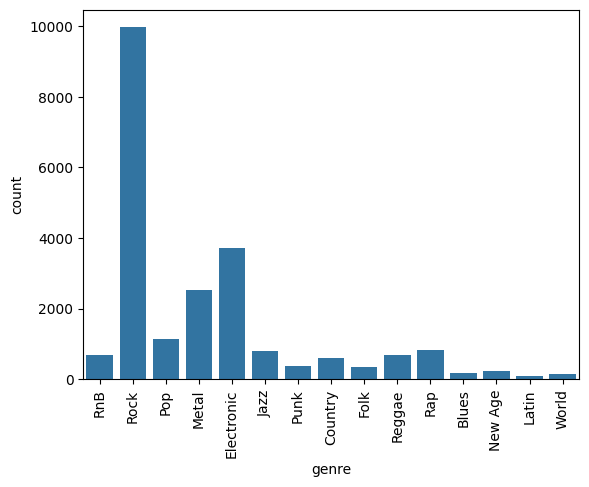

In [16]:
# Count plot of genre 

sns.countplot(df_song,x='genre')
plt.xticks(rotation=90)

In [24]:
## Integer based columns
integer_columns = df_song.select_dtypes(include='int').columns
integer_columns


Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='str')

In [25]:
df_song[integer_columns]

,year,duration_ms,key,mode,time_signature
0,2004,222200,1,1,4
1,2006,258613,2,1,4
2,1991,218920,4,0,4
3,2004,237026,9,1,4
4,2008,238640,7,1,4
...,...,...,...,...,...
50678,2008,273440,6,0,4
50679,2004,275133,0,1,4
50680,2014,254826,10,0,4
50681,2008,243293,4,0,4


<Axes: xlabel='year', ylabel='Count'>

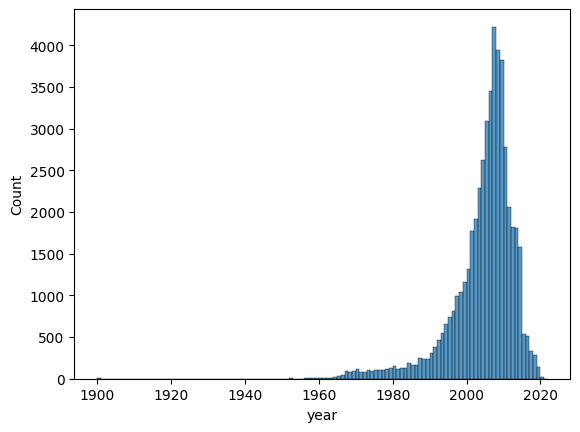

In [26]:
# no of song per year
sns.histplot(df_song,x='year',bins=df_song['year'].max() - df_song['year'].min(),stat='count')

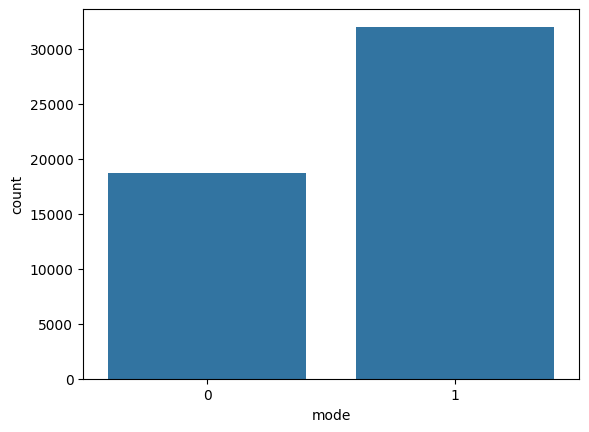

In [27]:
# Counterplot for mode

sns.countplot(df_song,x='mode')
plt.show()

<Axes: xlabel='time_signature', ylabel='count'>

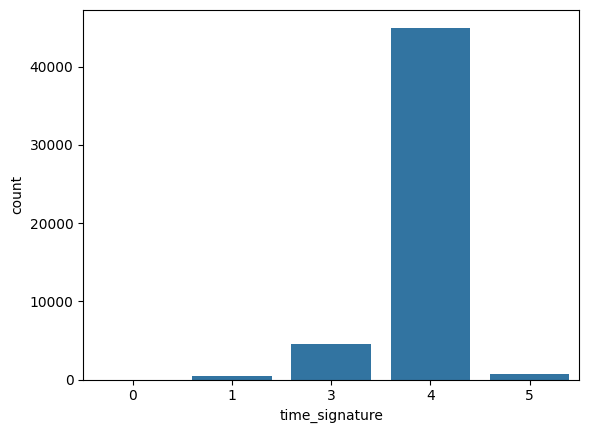

In [28]:
# countplot for time signature
sns.countplot(df_song,x="time_signature")

In [29]:
continious_columns = df_song.select_dtypes(include='float').columns
continious_columns

Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo'],
      dtype='str')

#### Users & Song Data

In [30]:
df_users = pd.read_csv(users_data_path)

In [31]:
df_users.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [32]:
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 9711301 entries, 0 to 9711300
Data columns (total 3 columns):
 #   Column     Dtype
---  ------     -----
 0   track_id   str  
 1   user_id    str  
 2   playcount  int64
dtypes: int64(1), str(2)
memory usage: 222.3 MB


In [34]:
df_users.duplicated(subset=['track_id','user_id']).sum()

np.int64(0)

In [35]:
df_users.isna().sum()

track_id     0
user_id      0
playcount    0
dtype: int64

In [36]:
df_users.loc[:,"user_id"].nunique()

962037

In [37]:
df_users['track_id'].nunique()

30459

In [43]:
top_10_track = df_users['track_id'].value_counts()[:10]
top_10_track

track_id
TRONYHY128F92C9D11    80656
TRUFTBY128F93450B8    39529
TRXWAZC128F9314B3E    30873
TRCPXID128F92D5D3C    30057
TRGCHLH12903CB7352    29708
TROMKCG128F9320C09    28735
TRPFYYL128F92F7144    28412
TRPGPDK12903CCC651    27276
TRWAQOC12903CB84CA    27222
TRAALAH128E078234A    26689
Name: count, dtype: int64

In [44]:
top_10_playcount = df_users.groupby('track_id')['playcount'].aggregate('sum').sort_values(ascending=False).head(10)
top_10_playcount

track_id
TRONYHY128F92C9D11    527893
TRUFTBY128F93450B8    111615
TRZNAHL128F9327D5A    111596
TRCPXID128F92D5D3C     91461
TRPGPDK12903CCC651     91448
TRXWAZC128F9314B3E     87745
TROMKCG128F9320C09     87050
TRPFYYL128F92F7144     85079
TRGCHLH12903CB7352     78443
TRAALAH128E078234A     76893
Name: playcount, dtype: int64

In [46]:
pd.concat([top_10_track,top_10_playcount],axis=1)

,count,playcount
track_id,,
TRONYHY128F92C9D11,80656.0,527893.0
TRUFTBY128F93450B8,39529.0,111615.0
TRXWAZC128F9314B3E,30873.0,87745.0
TRCPXID128F92D5D3C,30057.0,91461.0
TRGCHLH12903CB7352,29708.0,78443.0
TROMKCG128F9320C09,28735.0,87050.0
TRPFYYL128F92F7144,28412.0,85079.0
TRPGPDK12903CCC651,27276.0,91448.0
TRWAQOC12903CB84CA,27222.0,NaN


In [47]:
most_diverse_user = df_users.groupby("user_id")['track_id'].aggregate('count').sort_values(ascending=False).head(10)
most_diverse_user

user_id
ec6dfcf19485cb011e0b22637075037aae34cf26    784
4e11f45d732f4861772b2906f81a7d384552ad12    384
726da71c2c2ea119119a7957517fccd028d1be76    376
113255a012b2affeab62607563d03fbdf31b08e7    367
7adec7f006cb09482d36609d205293d8b61f030e    366
fef771ab021c200187a419f5e55311390f850a50    363
8cb51abc6bf8ea29341cb070fe1e1af5e4c3ffcc    362
b4c94d72b15d3c311c10045a58b31f95d9d12785    357
96f7b4f800cafef33eae71a6bc44f7139f63cd7a    356
6d625c6557df84b60d90426c0116138b617b9449    350
Name: track_id, dtype: int64

In [48]:
most_active_user = df_users.groupby('user_id')['playcount'].aggregate('sum').sort_values(ascending=False).head(10)

In [49]:
most_active_user

user_id
1854daf178674bbac9a8ed3d481f95b76676b414    2953
944cdf52364f45b0edd1c972b5a73d3a86b09c6a    2046
6a8a142084a4818c0dcac48bdfb3c39deacf5168    1942
93158e3983ffc8945e25c793d93d6b67d46cae9d    1845
f0b5c784daaa3c7d50acbb3723c7dd649db2b231    1841
6a58f480d522814c087fd3f8c77b3f32bb161f9d    1783
49127655d27dabab3f469bcdd996330fe4f3e210    1743
3fa44653315697f42410a30cb766a4eb102080bb    1639
839223f11c98e0c8017e8ecd6fc7b8706658c966    1608
af3ee32357049dd96231238bd1b019e8142ee6aa    1579
Name: playcount, dtype: int64